# Baseline Training and Evaluation Report

This notebook summarizes the frozen reference S8-CFD baseline experiment from committed validation artifacts in `reports/experiments/baseline-s8-cfd-960-s8/`.

The analysis is artifact-only: it does not retrain the detector, load a checkpoint, read or evaluate the sealed test split, or modify S8-CFD architecture, target encoding, loss, or evaluation semantics.

The purpose of this experiment is to establish the first controlled reference detector, evaluate whether the from-scratch S8-CFD formulation is viable, and identify the main weaknesses before changing architecture, loss terms, or training strategy.

## 1. Setup and Artifact Inventory

The notebook uses repository-relative paths and loads only saved JSON/CSV/image artifacts from the frozen baseline experiment directory.

In [1]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

EXPERIMENT_DIR = PROJECT_ROOT / "reports" / "experiments" / "baseline-s8-cfd-960-s8"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

REQUIRED_ARTIFACTS = {
    "config": EXPERIMENT_DIR / "config.json",
    "training_history_csv": EXPERIMENT_DIR / "training_history.csv",
    "training_history_json": EXPERIMENT_DIR / "training_history.json",
    "best_checkpoint": EXPERIMENT_DIR / "metrics" / "best_checkpoint.json",
    "threshold_broad_csv": EXPERIMENT_DIR / "threshold" / "broad" / "threshold_analysis.csv",
    "threshold_broad_json": EXPERIMENT_DIR / "threshold" / "broad" / "threshold_analysis.json",
    "threshold_refined_csv": EXPERIMENT_DIR / "threshold" / "threshold_analysis.csv",
    "threshold_refined_json": EXPERIMENT_DIR / "metrics" / "threshold_analysis.json",
    "val_metrics": EXPERIMENT_DIR / "metrics" / "val_inference_metrics.json",
    "qual_metrics": EXPERIMENT_DIR / "qualitative" / "val_inference_metrics.json",
    "qual_predictions": EXPERIMENT_DIR / "qualitative" / "predictions.csv",
    "qual_examples": EXPERIMENT_DIR / "qualitative" / "examples",
}

missing = {name: path for name, path in REQUIRED_ARTIFACTS.items() if not path.exists()}
if missing:
    raise FileNotFoundError("Missing required artifacts: " + ", ".join(f"{name}={path}" for name, path in missing.items()))

artifact_inventory = []
for path in sorted(EXPERIMENT_DIR.rglob("*")):
    if path.is_file():
        artifact_inventory.append({
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "size_kib": path.stat().st_size / 1024,
        })

artifact_df = pd.DataFrame(artifact_inventory)
display(artifact_df)

,relative_path,size_kib
0,reports/experiments/baseline-s8-cfd-960-s8/con...,2.161133
1,reports/experiments/baseline-s8-cfd-960-s8/met...,0.160156
2,reports/experiments/baseline-s8-cfd-960-s8/met...,5.781250
3,reports/experiments/baseline-s8-cfd-960-s8/met...,1.409180
4,reports/experiments/baseline-s8-cfd-960-s8/qua...,1132.060547
5,reports/experiments/baseline-s8-cfd-960-s8/qua...,1183.985352
6,reports/experiments/baseline-s8-cfd-960-s8/qua...,1429.055664
7,reports/experiments/baseline-s8-cfd-960-s8/qua...,1558.584961
8,reports/experiments/baseline-s8-cfd-960-s8/qua...,865.523438
9,reports/experiments/baseline-s8-cfd-960-s8/qua...,942.643555


## 2. Load Frozen Baseline Artifacts

Configuration, training history, validation metrics, threshold sweep, and qualitative prediction rows are loaded from disk. Cross-check assertions are intentionally placed near the loads so stale or inconsistent artifacts fail loudly.

In [2]:
def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

config = load_json(REQUIRED_ARTIFACTS["config"])
best_checkpoint = load_json(REQUIRED_ARTIFACTS["best_checkpoint"])
val_metrics = load_json(REQUIRED_ARTIFACTS["val_metrics"])
qual_metrics = load_json(REQUIRED_ARTIFACTS["qual_metrics"])
broad_threshold_json = load_json(REQUIRED_ARTIFACTS["threshold_broad_json"])
refined_threshold_json = load_json(REQUIRED_ARTIFACTS["threshold_refined_json"])

history_df = pd.read_csv(REQUIRED_ARTIFACTS["training_history_csv"])
broad_threshold_df = pd.read_csv(REQUIRED_ARTIFACTS["threshold_broad_csv"])
refined_threshold_df = pd.read_csv(REQUIRED_ARTIFACTS["threshold_refined_csv"])
predictions_df = pd.read_csv(REQUIRED_ARTIFACTS["qual_predictions"])
example_paths = sorted(REQUIRED_ARTIFACTS["qual_examples"].glob("*.png"))

assert config["run_name"] == "baseline-s8-cfd-960-s8"
assert best_checkpoint["metric_name"] == "val_map50_95"
assert int(best_checkpoint["best_epoch"]) == 19
assert math.isclose(float(best_checkpoint["best_metric"]), 0.4791892207620549, rel_tol=0, abs_tol=1e-9)
assert int(val_metrics["checkpoint_epoch"]) == 19
assert val_metrics["split"] == "val"
assert val_metrics["eval_confidence_floor"] == 0.001
assert math.isclose(float(val_metrics["map50_95"]), float(best_checkpoint["best_metric"]), rel_tol=0, abs_tol=1e-9)

print(f"Loaded {len(history_df)} training epochs.")
print(f"Loaded {len(broad_threshold_df)} broad threshold rows.")
print(f"Loaded {len(refined_threshold_df)} refined threshold rows.")
print(f"Loaded {len(predictions_df)} operating-threshold predictions.")
print(f"Loaded {len(example_paths)} qualitative examples.")

Loaded 20 training epochs.
Loaded 100 broad threshold rows.
Loaded 20 refined threshold rows.
Loaded 463 operating-threshold predictions.
Loaded 12 qualitative examples.


## 3. Baseline Configuration

The table below summarizes the reference baseline configuration from `config.json`, with detector details read from the saved `detector_config` block.

In [3]:
detector_config = config.get("detector_config", {})
loss_config = config.get("loss_config", detector_config)
config_table = pd.DataFrame([
    {"field": "model", "value": "S8-CFD — Stride-8 Context-Fused Drone Detector"},
    {"field": "input resolution", "value": f"{detector_config.get('input_width')} x {detector_config.get('input_height')}"},
    {"field": "output stride", "value": detector_config.get("stride")},
    {"field": "trainable parameters", "value": f"{int(config.get('trainable_parameters')):,}"},
    {"field": "epochs", "value": config.get("train_epochs")},
    {"field": "batch size", "value": config.get("batch_size")},
    {"field": "learning rate", "value": config.get("learning_rate")},
    {"field": "weight decay", "value": config.get("weight_decay")},
    {"field": "scheduler", "value": config.get("lr_scheduler")},
    {"field": "seed", "value": config.get("seed")},
    {"field": "checkpoint-selection metric", "value": config.get("best_checkpoint_metric")},
    {"field": "device", "value": config.get("selected_device")},
    {"field": "GPU", "value": config.get("cuda_gpu")},
])
display(config_table)

loss_statement = (
    f"L = {loss_config.get('lambda_obj', 1.0):g} L_obj + "
    f"{loss_config.get('lambda_center', 5.0):g} L_center + "
    f"{loss_config.get('lambda_size', 2.0):g} L_size"
)
display(Markdown(f"**Baseline loss:** `{loss_statement}` with balanced BCE objectness and Smooth L1 center/size regression."))

,field,value
0,model,S8-CFD — Stride-8 Context-Fused Drone Detector
1,input resolution,960 x 544
2,output stride,8
3,trainable parameters,"3,242,589"
4,epochs,20
5,batch size,2
6,learning rate,0.001
7,weight decay,0.0001
8,scheduler,none
9,seed,42


**Baseline loss:** `L = 1 L_obj + 5 L_center + 2 L_size` with balanced BCE objectness and Smooth L1 center/size regression.

## 4. Training and Validation Losses

Loss curves are read from `training_history.csv`. The component losses are shown separately so objectness and localization behavior can be interpreted without compressing everything into total loss.

Saved reports/figures/baseline_s8_cfd_total_loss.png and reports/figures/baseline_s8_cfd_total_loss.pdf


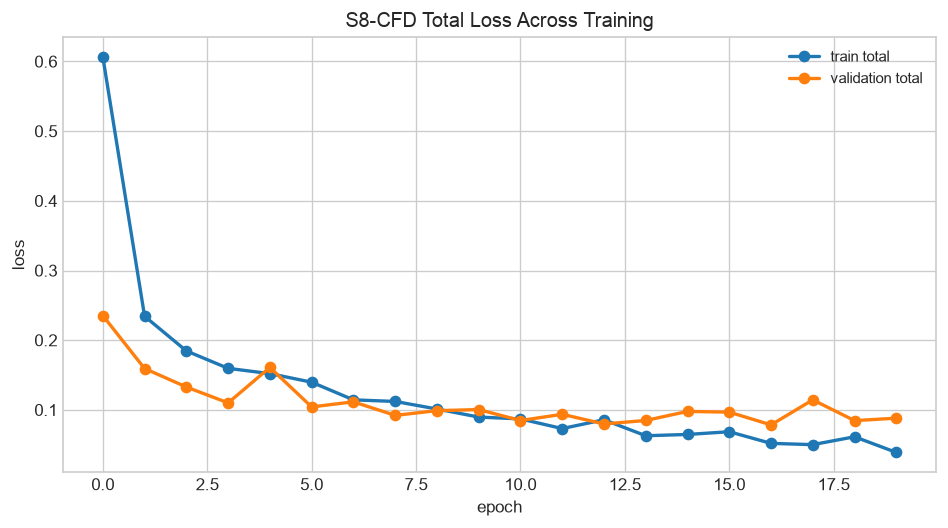

Saved reports/figures/baseline_s8_cfd_component_losses.png and reports/figures/baseline_s8_cfd_component_losses.pdf


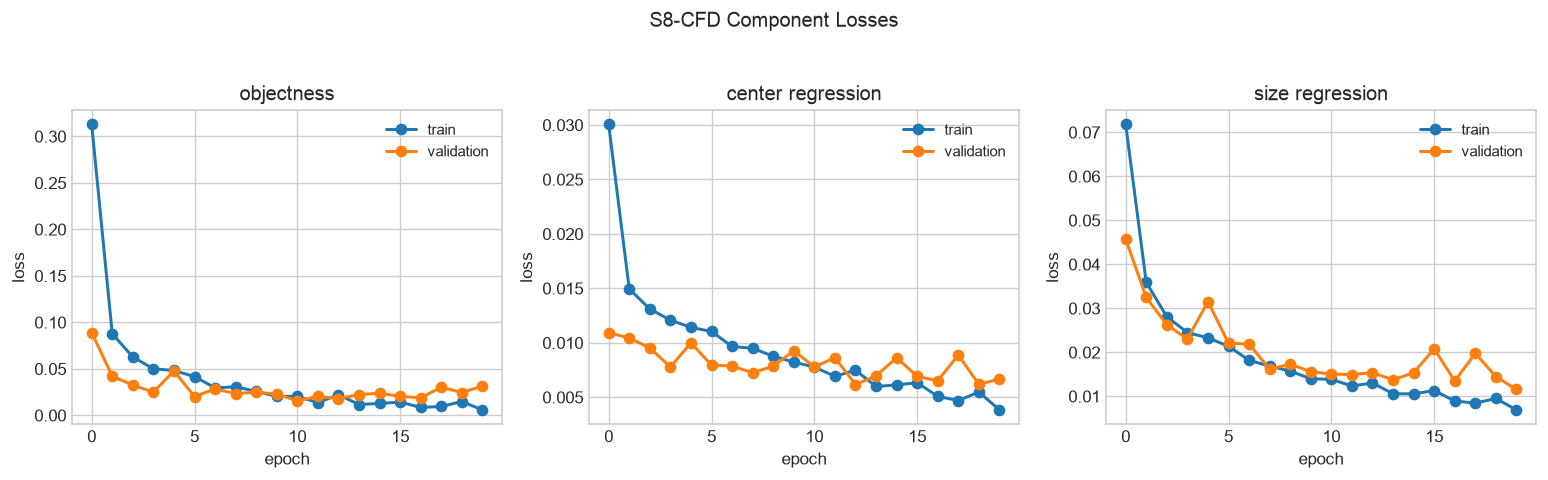

In [4]:
def save_figure(fig: plt.Figure, name: str) -> None:
    png_path = FIGURE_DIR / f"{name}.png"
    pdf_path = FIGURE_DIR / f"{name}.pdf"
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved {png_path.relative_to(PROJECT_ROOT)} and {pdf_path.relative_to(PROJECT_ROOT)}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(history_df["epoch"], history_df["train_total"], marker="o", linewidth=2, label="train total")
ax.plot(history_df["epoch"], history_df["val_total"], marker="o", linewidth=2, label="validation total")
ax.set_title("S8-CFD Total Loss Across Training")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend()
fig.tight_layout()
save_figure(fig, "baseline_s8_cfd_total_loss")
plt.show()

components = [
    ("objectness", "train_objectness", "val_objectness"),
    ("center regression", "train_center", "val_center"),
    ("size regression", "train_size", "val_size"),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)
for ax, (title, train_col, val_col) in zip(axes, components):
    ax.plot(history_df["epoch"], history_df[train_col], marker="o", linewidth=1.8, label="train")
    ax.plot(history_df["epoch"], history_df[val_col], marker="o", linewidth=1.8, label="validation")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()
fig.suptitle("S8-CFD Component Losses", y=1.04)
fig.tight_layout()
save_figure(fig, "baseline_s8_cfd_component_losses")
plt.show()

The total training loss falls steadily over the 20 epochs, while validation loss improves overall but does not move monotonically. This supports the view that S8-CFD is learning the task, but the late-stage validation behavior is volatile enough that blindly extending the same fixed-learning-rate run to 50 epochs is not the cleanest immediate next step. A controlled learning-rate schedule experiment is better motivated than simply training longer under identical settings.

## 5. AP Curves and Best Checkpoint

AP is evaluated from ranked predictions produced with `EVAL_CONFIDENCE_FLOOR=0.001`. It is conceptually separate from the selected operating/display threshold.

Saved reports/figures/baseline_s8_cfd_validation_ap.png and reports/figures/baseline_s8_cfd_validation_ap.pdf


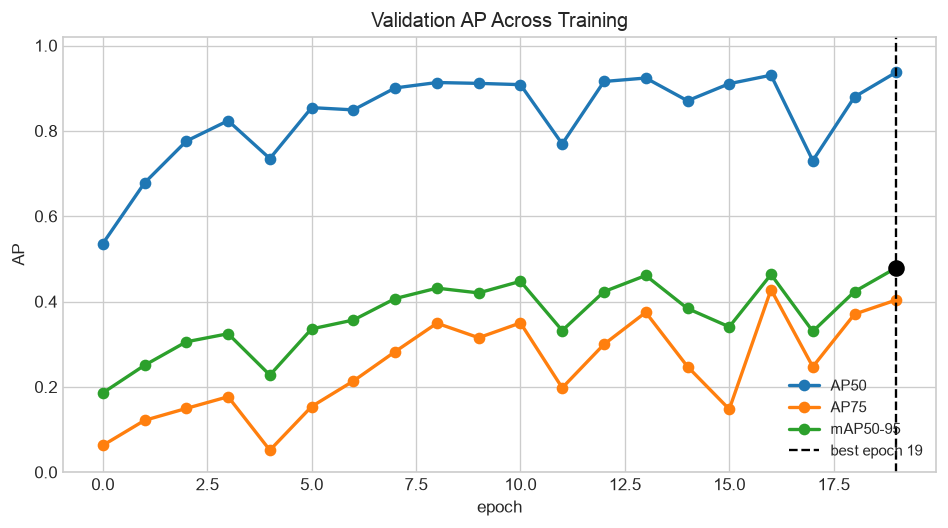

,metric,value
0,best epoch,19.000000
1,AP50,0.937563
2,AP75,0.403768
3,mAP50-95,0.479189


In [5]:
best_epoch = int(best_checkpoint["best_epoch"])
best_metric = float(best_checkpoint["best_metric"])
best_row = history_df.loc[history_df["epoch"] == best_epoch].iloc[0]

assert math.isclose(float(best_row["val_map50_95"]), best_metric, rel_tol=0, abs_tol=1e-9)
assert math.isclose(float(val_metrics["ap50"]), float(best_row["val_ap50"]), rel_tol=0, abs_tol=1e-9)
assert math.isclose(float(val_metrics["ap75"]), float(best_row["val_ap75"]), rel_tol=0, abs_tol=1e-9)

fig, ax = plt.subplots(figsize=(8, 4.5))
for col, label in [("val_ap50", "AP50"), ("val_ap75", "AP75"), ("val_map50_95", "mAP50-95")]:
    ax.plot(history_df["epoch"], history_df[col], marker="o", linewidth=2, label=label)
ax.axvline(best_epoch, color="black", linestyle="--", linewidth=1.4, label=f"best epoch {best_epoch}")
ax.scatter([best_epoch], [best_metric], s=80, color="black", zorder=5)
ax.set_title("Validation AP Across Training")
ax.set_xlabel("epoch")
ax.set_ylabel("AP")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "baseline_s8_cfd_validation_ap")
plt.show()

headline_metrics = pd.DataFrame([
    {"metric": "best epoch", "value": best_epoch},
    {"metric": "AP50", "value": float(val_metrics["ap50"])},
    {"metric": "AP75", "value": float(val_metrics["ap75"])},
    {"metric": "mAP50-95", "value": float(val_metrics["map50_95"])},
])
display(headline_metrics)

The best validation checkpoint occurs at epoch 19 with mAP50-95 near 0.47919. AP50 near 0.938 indicates strong coarse detection: the model usually finds the drone region at a forgiving IoU threshold. AP75 near 0.404 is much lower, which points to stricter bounding-box localization as the main measurable weakness. This motivates a later localization-loss experiment, but does not by itself prove which localization loss will work best.

## 6. Throughput and CUDA Telemetry

The training history includes runtime telemetry from the official 20-epoch Windows CUDA baseline run. These values are reported as saved; the notebook does not query local GPU hardware.


In [6]:
telemetry_cols = [
    "epoch",
    "epoch_duration_sec",
    "train_images_per_sec",
    "val_images_per_sec",
    "cuda_peak_allocated_mb",
    "cuda_peak_reserved_mb",
    "cuda_gpu",
]
telemetry_df = history_df[telemetry_cols].copy()
display(telemetry_df.describe(include="all").transpose())

gpu_values = sorted(str(value) for value in telemetry_df["cuda_gpu"].dropna().unique())
if gpu_values:
    display(Markdown("**GPU reported by artifacts:** " + ", ".join(gpu_values)))
else:
    display(Markdown("**GPU reported by artifacts:** not available"))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
epoch,20.0,NaN,NaN,NaN,9.5,5.91608,0.0,4.75,9.5,14.25,19.0
epoch_duration_sec,20.0,NaN,NaN,NaN,257.9762,13.62243,202.3532,257.953019,260.273972,262.409608,272.062552
train_images_per_sec,20.0,NaN,NaN,NaN,8.653734,0.808092,8.069331,8.432342,8.501681,8.576594,12.041315
val_images_per_sec,20.0,NaN,NaN,NaN,7.976295,0.156482,7.690761,7.925729,7.995954,8.01511,8.240476
cuda_peak_allocated_mb,20.0,NaN,NaN,NaN,479.520996,0.0,479.520996,479.520996,479.520996,479.520996,479.520996
cuda_peak_reserved_mb,20.0,NaN,NaN,NaN,590.0,0.0,590.0,590.0,590.0,590.0,590.0
cuda_gpu,20,1,NVIDIA GeForce GTX 1660 SUPER,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**GPU reported by artifacts:** NVIDIA GeForce GTX 1660 SUPER

## 7. Operating Threshold Analysis

The threshold sweep is validation-only. It selects a display/operating threshold for precision, recall, and F1; it does not define AP.

,sweep,source,rows,min_threshold,max_threshold,best_threshold,best_f1
0,broad,reports/experiments/baseline-s8-cfd-960-s8/thr...,100,0.900,0.99900,0.999,0.933893
1,refined,reports/experiments/baseline-s8-cfd-960-s8/thr...,20,0.999,0.99995,0.999,0.933893


Saved reports/figures/baseline_s8_cfd_threshold_metrics.png and reports/figures/baseline_s8_cfd_threshold_metrics.pdf


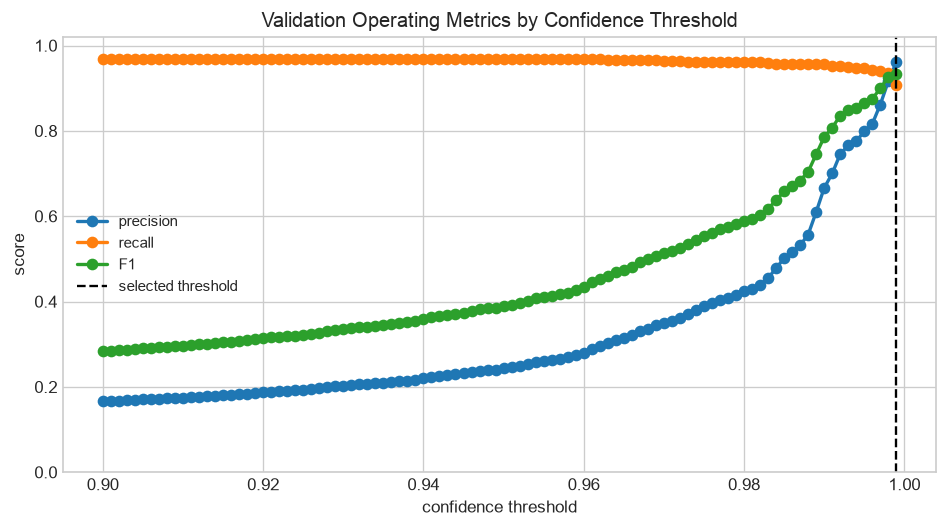

Saved reports/figures/baseline_s8_cfd_precision_recall_threshold_curve.png and reports/figures/baseline_s8_cfd_precision_recall_threshold_curve.pdf


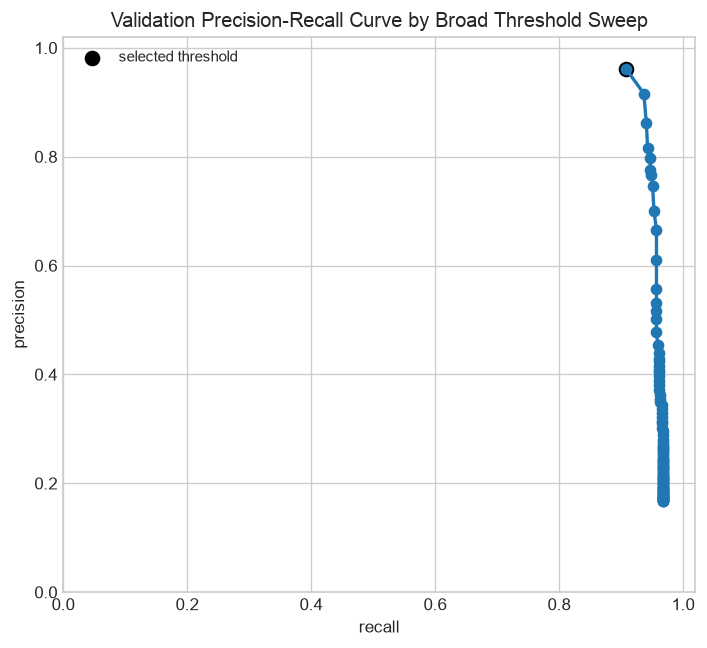

Saved reports/figures/baseline_s8_cfd_predictions_per_image_threshold.png and reports/figures/baseline_s8_cfd_predictions_per_image_threshold.pdf


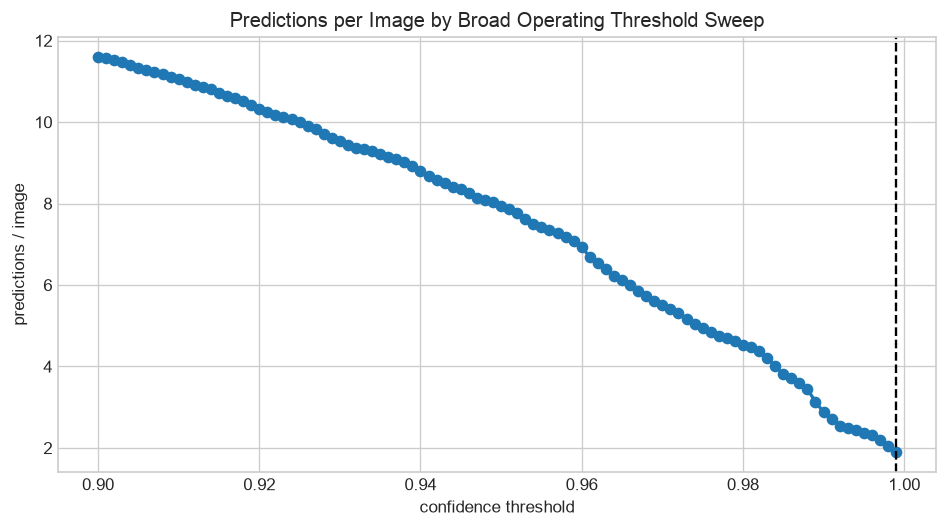

,metric,value
0,selected threshold,0.999000
1,precision,0.961123
2,recall,0.908163
3,F1,0.933893
4,true positives,445.000000
5,false positives,18.000000
6,false negatives,45.000000
7,predictions,463.000000
8,predictions / image,1.889796


In [7]:
def best_threshold_row(df: pd.DataFrame) -> dict[str, float]:
    return df.sort_values(["f1", "precision", "recall"], ascending=False).iloc[0].to_dict()


broad_best = best_threshold_row(broad_threshold_df)
refined_best = best_threshold_row(refined_threshold_df)
threshold_best = val_metrics.get("threshold_analysis_best_f1") or refined_best

for key in ["threshold", "precision", "recall", "f1"]:
    assert math.isclose(float(threshold_best[key]), float(refined_best[key]), rel_tol=0, abs_tol=1e-9)

assert math.isclose(float(threshold_best["threshold"]), 0.999, rel_tol=0, abs_tol=1e-12)
assert math.isclose(float(threshold_best["precision"]), float(val_metrics["precision"]), rel_tol=0, abs_tol=1e-9)
assert math.isclose(float(threshold_best["recall"]), float(val_metrics["recall"]), rel_tol=0, abs_tol=1e-9)
assert math.isclose(float(threshold_best["f1"]), float(val_metrics["f1"]), rel_tol=0, abs_tol=1e-9)

threshold_sweep_summary = pd.DataFrame([
    {
        "sweep": "broad",
        "source": str(REQUIRED_ARTIFACTS["threshold_broad_csv"].relative_to(PROJECT_ROOT)),
        "rows": len(broad_threshold_df),
        "min_threshold": broad_threshold_df["threshold"].min(),
        "max_threshold": broad_threshold_df["threshold"].max(),
        "best_threshold": broad_best["threshold"],
        "best_f1": broad_best["f1"],
    },
    {
        "sweep": "refined",
        "source": str(REQUIRED_ARTIFACTS["threshold_refined_csv"].relative_to(PROJECT_ROOT)),
        "rows": len(refined_threshold_df),
        "min_threshold": refined_threshold_df["threshold"].min(),
        "max_threshold": refined_threshold_df["threshold"].max(),
        "best_threshold": refined_best["threshold"],
        "best_f1": refined_best["f1"],
    },
])
display(threshold_sweep_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
for col, label in [("precision", "precision"), ("recall", "recall"), ("f1", "F1")]:
    ax.plot(broad_threshold_df["threshold"], broad_threshold_df[col], marker="o", linewidth=2, label=label)
ax.axvline(float(threshold_best["threshold"]), color="black", linestyle="--", linewidth=1.4, label="selected threshold")
ax.set_title("Validation Operating Metrics by Confidence Threshold")
ax.set_xlabel("confidence threshold")
ax.set_ylabel("score")
ax.set_ylim(0, 1.02)
ax.legend()
fig.tight_layout()
save_figure(fig, "baseline_s8_cfd_threshold_metrics")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(broad_threshold_df["recall"], broad_threshold_df["precision"], marker="o", linewidth=2)
ax.scatter([threshold_best["recall"]], [threshold_best["precision"]], color="black", s=70, label="selected threshold")
ax.set_title("Validation Precision-Recall Curve by Broad Threshold Sweep")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.legend()
fig.tight_layout()
save_figure(fig, "baseline_s8_cfd_precision_recall_threshold_curve")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(broad_threshold_df["threshold"], broad_threshold_df["predictions_per_image"], marker="o", linewidth=2)
ax.axvline(float(threshold_best["threshold"]), color="black", linestyle="--", linewidth=1.4)
ax.set_title("Predictions per Image by Broad Operating Threshold Sweep")
ax.set_xlabel("confidence threshold")
ax.set_ylabel("predictions / image")
fig.tight_layout()
save_figure(fig, "baseline_s8_cfd_predictions_per_image_threshold")
plt.show()

operating_table = pd.DataFrame([
    {"metric": "selected threshold", "value": threshold_best["threshold"]},
    {"metric": "precision", "value": threshold_best["precision"]},
    {"metric": "recall", "value": threshold_best["recall"]},
    {"metric": "F1", "value": threshold_best["f1"]},
    {"metric": "true positives", "value": threshold_best["true_positives"]},
    {"metric": "false positives", "value": threshold_best["false_positives"]},
    {"metric": "false negatives", "value": threshold_best["false_negatives"]},
    {"metric": "predictions", "value": threshold_best["predictions"]},
    {"metric": "predictions / image", "value": threshold_best["predictions_per_image"]},
])
display(operating_table)


The broad validation sweep source is used for the threshold-metric and predictions-per-image figures, while the refined sweep source is used only to verify and finalize the selected operating point. The intended sweep sequence is preserved explicitly: the broad sweep identified 0.999 as the best F1 threshold at its searched boundary, and the subsequent fine sweep confirmed that 0.999 remained the best F1 operating point. The sweep summary table reports the actual checked-in threshold range for each source so the two sweeps are not merged or treated as one uniformly spaced grid.

The selected validation operating threshold is 0.999, with precision near 0.961, recall near 0.908, and F1 near 0.934. The unusually high validation-selected operating threshold and score statistics indicate a highly concentrated/polarized confidence-score distribution. Formal probability calibration was not evaluated, so this does not by itself establish poor calibration.


## 8. Prediction Diagnostics

The final validation inference metrics separate dense raw predictions, low-floor AP candidates, post-NMS candidates, and operating-threshold display predictions.

In [8]:
diagnostic_fields = [
    "raw_predictions",
    "valid_predictions",
    "eval_score_filtered_predictions",
    "nms_candidate_predictions",
    "post_nms_predictions",
    "display_predictions",
    "post_nms_predictions_per_image",
    "display_predictions_per_image",
    "true_positives",
    "false_positives",
    "false_negatives",
]
diagnostics_table = pd.DataFrame([
    {"metric": field, "value": val_metrics.get(field)}
    for field in diagnostic_fields
])
display(diagnostics_table)

display(pd.DataFrame([val_metrics.get("score_distribution_after_eval_nms", {})]).transpose().rename(columns={0: "score"}))

prediction_summary = pd.DataFrame([
    {"metric": "prediction rows at operating threshold", "value": len(predictions_df)},
    {"metric": "unique predicted images", "value": predictions_df["image_file"].nunique()},
    {"metric": "mean score", "value": predictions_df["score"].mean()},
    {"metric": "min score", "value": predictions_df["score"].min()},
    {"metric": "max score", "value": predictions_df["score"].max()},
])
display(prediction_summary)

,metric,value
0,raw_predictions,1.999200e+06
1,valid_predictions,1.999200e+06
2,eval_score_filtered_predictions,6.157000e+04
3,nms_candidate_predictions,6.156100e+04
4,post_nms_predictions,2.244800e+04
5,display_predictions,4.630000e+02
6,post_nms_predictions_per_image,9.162449e+01
7,display_predictions_per_image,1.889796e+00
8,true_positives,4.450000e+02
9,false_positives,1.800000e+01


,score
min,0.001001
p25,0.015159
median,0.103293
p75,0.546144
max,0.999999
mean,0.292811


,metric,value
0,prediction rows at operating threshold,463.000000
1,unique predicted images,239.000000
2,mean score,0.999828
3,min score,0.999014
4,max score,0.999999


The saved metrics provide exact aggregate false positives, false negatives, and true positives at the selected operating threshold. The saved `predictions.csv` contains predicted boxes and scores, but it does not include ground-truth boxes, match IDs, or failure labels. Therefore this notebook cannot reconstruct exact per-image error categories such as localization-only failures versus duplicate detections without re-running evaluation or loading labels. The limitation is intentional here: this notebook reports only what the frozen artifacts support.

## 9. Qualitative Examples

The qualitative examples are saved prediction renderings from validation images. The labels below are parsed from filenames only; no scenario information is invented beyond the file names.

,file,raw_or_augmented,scene,weather
0,0008_augmented_raw_dataset_city_foggy_city_fog...,augmented,city,foggy
1,0024_augmented_raw_dataset_city_sunny_city_sun...,augmented,city,sunny
2,0045_augmented_raw_dataset_forest_foggy_forest...,augmented,forest,foggy
3,0068_augmented_raw_dataset_forest_sunny_forest...,augmented,forest,sunny
4,0088_augmented_raw_dataset_lake_foggy_lake_fog...,augmented,lake,foggy
5,0110_augmented_raw_dataset_lake_sunny_lake_sun...,augmented,lake,sunny
6,0134_raw_dataset_city_foggy_city_foggy_8_9_seq...,raw,city,foggy
7,0154_raw_dataset_city_sunny_city_sunny_8_9_seq...,raw,city,sunny
8,0174_raw_dataset_forest_foggy_forest_foggy_8_9...,raw,forest,foggy
9,0197_raw_dataset_forest_sunny_forest_sunny_8_9...,raw,forest,sunny


Saved reports/figures/baseline_s8_cfd_qualitative_examples.png and reports/figures/baseline_s8_cfd_qualitative_examples.pdf


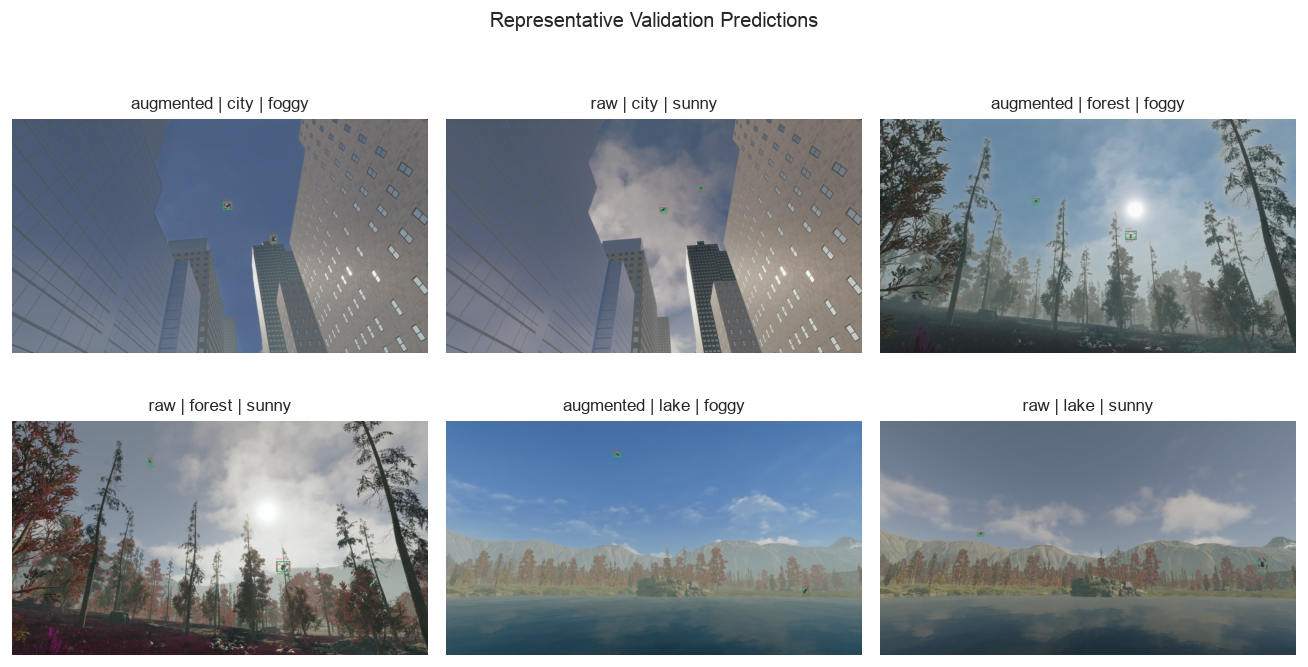

In [9]:
def parse_example_name(path: Path) -> dict[str, str]:
    name = path.name
    encoded_name = re.sub(r"^\d+_", "", path.stem)
    if encoded_name.startswith("augmented_"):
        raw_or_augmented = "augmented"
    elif encoded_name.startswith("raw_"):
        raw_or_augmented = "raw"
    else:
        raw_or_augmented = "unknown"
    scene = "unknown"
    weather = "unknown"
    for scene_candidate in ["city", "forest", "lake"]:
        if f"_{scene_candidate}_" in name:
            scene = scene_candidate
            break
    for weather_candidate in ["sunny", "foggy"]:
        if f"_{weather_candidate}_" in name:
            weather = weather_candidate
            break
    return {
        "file": name,
        "raw_or_augmented": raw_or_augmented,
        "scene": scene,
        "weather": weather,
    }

example_meta = pd.DataFrame([parse_example_name(path) for path in example_paths])
display(example_meta)

# Select one image per scene/weather pair, alternating raw and augmented examples when available.
selected_examples = []
preferred_kind = {
    ("city", "foggy"): "augmented",
    ("city", "sunny"): "raw",
    ("forest", "foggy"): "augmented",
    ("forest", "sunny"): "raw",
    ("lake", "foggy"): "augmented",
    ("lake", "sunny"): "raw",
}
for (scene, weather), kind in preferred_kind.items():
    subset = example_meta[(example_meta["scene"] == scene) & (example_meta["weather"] == weather)]
    preferred = subset[subset["raw_or_augmented"] == kind]
    chosen = preferred.iloc[0] if not preferred.empty else subset.iloc[0] if not subset.empty else None
    if chosen is not None:
        selected_examples.append(REQUIRED_ARTIFACTS["qual_examples"] / chosen["file"])

cols = 3
rows = math.ceil(len(selected_examples) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(11, 3.0 * rows))
axes = np.array(axes).reshape(-1)
for ax, path in zip(axes, selected_examples):
    with Image.open(path) as image:
        ax.imshow(image)
    meta = parse_example_name(path)
    ax.set_title(f"{meta['raw_or_augmented']} | {meta['scene']} | {meta['weather']}", fontsize=10)
    ax.axis("off")
for ax in axes[len(selected_examples):]:
    ax.axis("off")
fig.suptitle("Representative Validation Predictions", y=0.995)
fig.tight_layout()
save_figure(fig, "baseline_s8_cfd_qualitative_examples")
plt.show()

The qualitative panels cover city, forest, and lake backgrounds; sunny and foggy conditions; and both raw and augmented validation examples where saved. The renderings show a generally strong visual agreement between predicted and ground-truth regions at the selected threshold, while the AP50/AP75 gap remains a quantitative warning that box tightness is still inconsistent. Exact per-image false-positive, false-negative, or localization-failure labels are not available in the saved qualitative CSV, so this section stays visual and aggregate rather than inventing error categories.

## 10. Interpretation and Follow-up Hypotheses

The frozen S8-CFD baseline is viable: a from-scratch stride-8 context-fused detector reaches strong coarse detection performance on the validation split, with AP50 near 0.938 and operating-threshold F1 near 0.934. The main measurable weakness is stricter localization, visible in the gap between AP50 and AP75. Late validation volatility under fixed learning rate also suggests that simply extending the same run is less informative than a controlled training-schedule experiment.

Future hypotheses to test, in order:

1. Add an IoU-based localization term to directly reward tighter boxes.
2. Test LR scheduling or late-stage LR reduction to reduce validation volatility.
3. Test focal-style objectness only if subsequent error analysis supports an objectness imbalance or duplicate-candidate issue.
4. Test higher input resolution if time allows, balancing small-object detail against memory and throughput.

These are hypotheses, not proven improvements. The sealed test split remains untouched and should stay reserved for final evaluation only.

In [10]:
summary = {
    "run_name": config["run_name"],
    "best_epoch": best_epoch,
    "selection_metric": best_checkpoint["metric_name"],
    "map50_95": float(val_metrics["map50_95"]),
    "ap50": float(val_metrics["ap50"]),
    "ap75": float(val_metrics["ap75"]),
    "selected_threshold": float(threshold_best["threshold"]),
    "precision": float(threshold_best["precision"]),
    "recall": float(threshold_best["recall"]),
    "f1": float(threshold_best["f1"]),
    "test_split_evaluated": False,
}
display(pd.DataFrame([summary]).transpose().rename(columns={0: "value"}))

,value
run_name,baseline-s8-cfd-960-s8
best_epoch,19
selection_metric,val_map50_95
map50_95,0.479189
ap50,0.937563
ap75,0.403768
selected_threshold,0.999
precision,0.961123
recall,0.908163
f1,0.933893
